Gefundene Dateien:
- B007_0.mat
- IR021_1.mat
- main.ipynb
- main.py
- OR014@6_1.mat
Signale: (356, 1024)
Labels: (356,)
Feature-Matrix: (356, 53)
Beurteilungsreport:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        26
           2       1.00      1.00      1.00        21
           3       1.00      1.00      1.00        25

    accuracy                           1.00        72
   macro avg       1.00      1.00      1.00        72
weighted avg       1.00      1.00      1.00        72

Konfusions-Matrix:
[[26  0  0]
 [ 0 21  0]
 [ 0  0 25]]


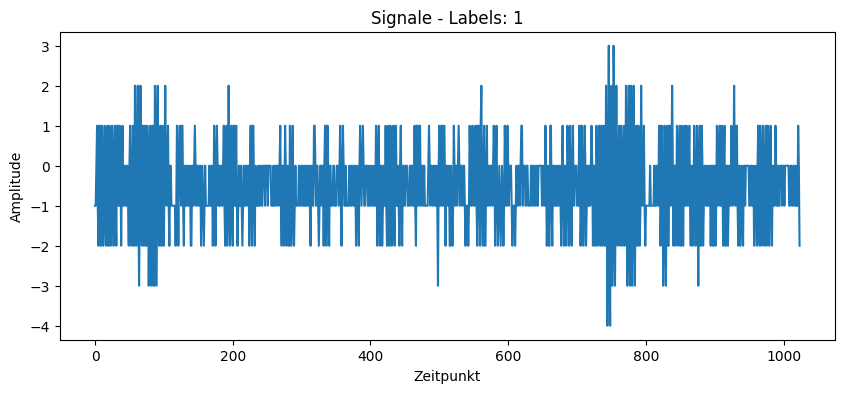

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from scipy.io import loadmat

#Dateipfad
data_ordner = "."

print("Gefundene Dateien:")
for file in os.listdir(data_ordner):
    print("-", file)

#Label Erkennung
def get_label_from_filename(filename):
    if "Normal" in filename:
        return 0 #gutteil
    elif "B" in filename:
        return 1 #defekt
    elif "IR" in filename:
        return 2 #defekt
    elif "OR" in filename: 
        return 3 #defekt
    else: 
        return -1 #fehler
    
#Fenster segmentieren 
def segment_signal(signal, fenster_gr=1024):
    n_fenster = signal.shape[1] // fenster_gr
    segmente = []
    for i in range(n_fenster):
        start = i * fenster_gr
        end = start + fenster_gr
        fenster = signal[0, start:end]
        #Normalisierung
        fenster = (fenster - np.mean(fenster)) // np.std(fenster)
        segmente.append(fenster)
    return np.array(segmente) 

#Feature erkennen
def extrahiere_features(signal):
    mittel_wert = np.mean(signal)
    stdab_wert = np.std(signal)
    max_wert = np.max(signal)
    fft_werte = np.abs(np.fft.fft(signal))[:50]
    feature = np.hstack([mittel_wert,stdab_wert,max_wert,fft_werte])
    return feature

#Dateien einlesen
alle_signale = []
alle_labels = []

for file in os.listdir(data_ordner):
    if file.endswith(".mat"):
        label = get_label_from_filename(file)
        if label == -1:
            continue
        file_path = os.path.join(data_ordner,file)

        mat_daten = loadmat(file_path)
        keys = [k for k in mat_daten.keys() if not k.startswith("__")]
        if not keys:
            continue
        key = keys[0]
        data = mat_daten[key].T
        segmente = segment_signal(data, fenster_gr=1024)
        alle_signale.extend(segmente)
        alle_labels.extend([label]*segmente.shape[0])

#Vektoren 
alle_signale = np.array(alle_signale)
alle_labels = np.array(alle_labels)

print("Signale:", alle_signale.shape)
print("Labels:", alle_labels.shape)

#Feature Matrix erstellen
x_feature = np.array([extrahiere_features(sig) for sig in alle_signale])
y_feature = alle_labels

print("Feature-Matrix:", x_feature.shape)

#Training und Testen 
x_train, x_test, y_train, y_test = train_test_split(
    x_feature,y_feature, test_size=0.2, random_state=42
    )

#Random Forest Modell
model = RandomForestClassifier(n_estimators=500, random_state=42)
model.fit(x_train,y_train)

#Vorhersage
y_vorhersage = model.predict(x_test)

#Beurteilung
print("Beurteilungsreport:")
print(classification_report(y_test,y_vorhersage))

print("Konfusions-Matrix:")
print(confusion_matrix(y_test,y_vorhersage))

#Signale plotten
plt.figure(figsize=(10,4))
plt.plot(alle_signale[0])
plt.title(f"Signale - Labels: {alle_labels[0]}")
plt.xlabel("Zeitpunkt")
plt.ylabel("Amplitude")
plt.show()